# Feature Transformation, Scaling, and Encoding


## Feature Transformation 

Feature transformation modifies the distribution of data to make it more suitable for modeling. It's useful for handling skewed data, stabilizing variance, or making data more normal-like.

### Why Transform Features?
- Reduce skewness.
- Handle outliers.
- Improve model performance (e.g., for linear models assuming normality).

### Techniques
1. **Log Transformation**: Useful for right-skewed data.
2. **Square Root Transformation**: Milder than log for skewed data.
3. **Box-Cox Transformation**: Power transformation that finds the best lambda.

In [52]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

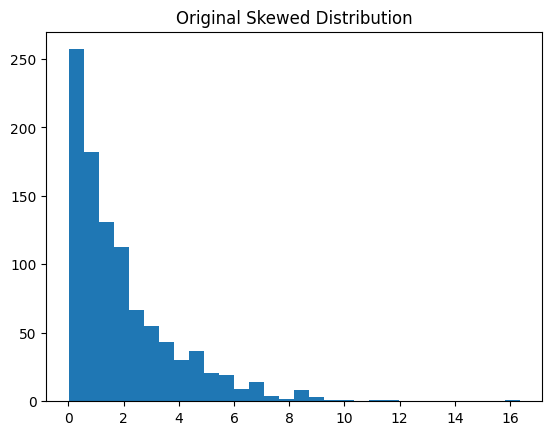

In [53]:
# Create a sample skewed dataset
np.random.seed(42)
data = np.random.exponential(scale=2, size=1000)
df = pd.DataFrame({'Original': data})

# Plot original distribution
plt.hist(df['Original'], bins=30)
plt.title('Original Skewed Distribution')
plt.show()

### 1. Log Transformation
A log transformation is a mathematical operation where we apply the logarithm function to data values.
Log transformations are widely used in data analysis and statistics for reducing skewness which make more symmetric with a log transformation. 

Log Transformation is oftenly used for right-skewed distributions.

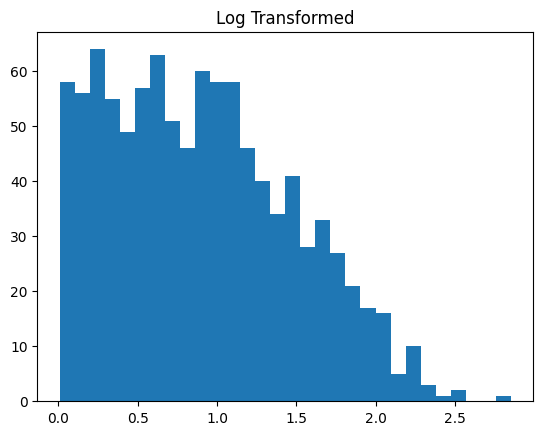

In [54]:
# Log transformation (add 1 to handle zeros)
df['Log'] = np.log1p(df['Original'])

# Plot
plt.hist(df['Log'], bins=30)
plt.title('Log Transformed')
plt.show()

### 2. Square Root Transformation

A square root transformation is a mathematical operation where we take the square root of a variable’s values. 

Unlike log transformation, square root can handle zero, but not negative numbers.



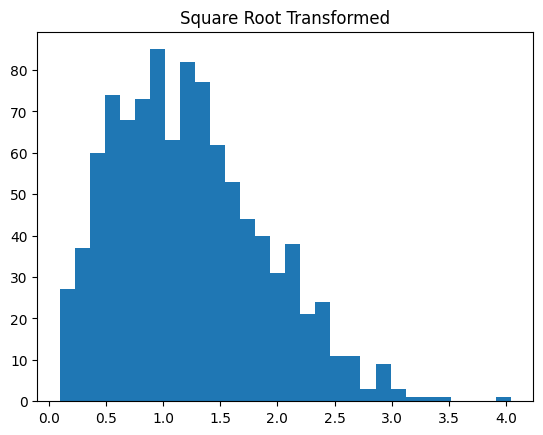

In [55]:
# Square root transformation
df['Sqrt'] = np.sqrt(df['Original'])

# Plot
plt.hist(df['Sqrt'], bins=30)
plt.title('Square Root Transformed')
plt.show()

### 3. Box-Cox Transformation

The Box-Cox transformation is a power transformation that helps make data more normally distributed and stabilize variance.

Box-Cox is more flexible than just log or square root because of its finding the best transformation automatically with the variance stabilization.

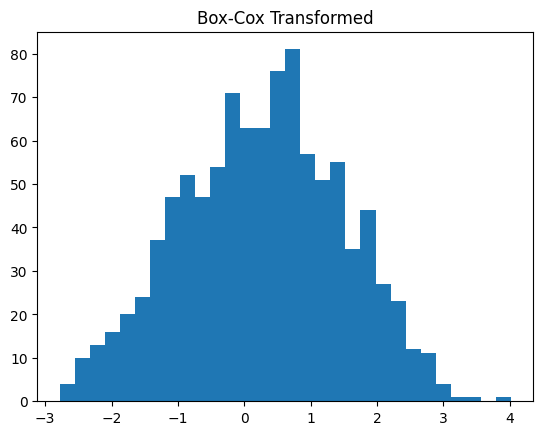

In [56]:
# Box-Cox (data must be positive)
df['BoxCox'], _ = stats.boxcox(df['Original'] + 1e-9)  # Add small value to avoid zero

# Plot
plt.hist(df['BoxCox'], bins=30)
plt.title('Box-Cox Transformed')
plt.show()

## Feature Scaling 

Feature scaling normalizes the range of features to a common scale. It's crucial for distance-based algorithms like KNN, SVM, and neural networks.

### Why Scale Features?
- Prevent features with larger magnitudes from dominating.
- Speed up convergence in gradient-based algorithms.
- Improve model interpretability.

### Techniques
1. **Standardization (Z-score)**: Mean 0, std 1.
2. **Min-Max Scaling**: Scale to [0,1] or custom range.
3. **Robust Scaling**: Uses median and IQR, robust to outliers.
4. **Normalization**: Scale to unit norm (e.g., L2 norm).

In [57]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer

In [58]:
# Sample dataset with different scales
data_scale = {
    'Feature1': np.random.normal(0, 1, 100),
    'Feature2': np.random.normal(100, 10, 100),
    'Feature3': np.random.normal(1000, 100, 100)
}
df_scale = pd.DataFrame(data_scale)
print("Original Data:")
print(df_scale.describe())
print(df_scale)

Original Data:
         Feature1    Feature2     Feature3
count  100.000000  100.000000   100.000000
mean     0.112377  101.613654  1012.284639
std      0.905637    9.845245    97.683918
min     -1.660961   75.761207   715.145738
25%     -0.524894   95.074069   949.587376
50%      0.056020  102.078357  1015.881547
75%      0.662613  107.497938  1080.190555
max      2.455300  125.269324  1214.227036
    Feature1    Feature2     Feature3
0   0.177701  125.269324  1078.580016
1  -1.335344   94.691312  1042.545756
2   0.380198   95.105606   903.302386
3   0.610586  110.441609   995.228864
4   0.559790  106.818915   999.639746
..       ...         ...          ...
95  1.794558   81.104593   950.624342
96 -0.517611   95.476937   844.341810
97  0.223788   75.761207   957.188484
98 -0.016423   84.160972  1150.075979
99  1.188393  107.604147  1085.022174

[100 rows x 3 columns]


### 1. Standardization

Standardization (also called Z-score normalization) is a technique to rescale data so that it has:

Mean = 0

Standard deviation = 1

The formula for standardization is:

z=(x−μ)/σ

Where:
- x = original value,
- μ = mean of the feature,
- σ = standard deviation of the feature,
- z = standardized value (z-score)


Standardization is used when features have different scales or units, the algorithm like KNN , K-Means, Neural Networks etc, that are sensitive to feature scale.

In [59]:
scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(df_scale), columns=df_scale.columns)
print("\nStandardized Data:")
print(df_std.describe())


Standardized Data:
           Feature1      Feature2      Feature3
count  1.000000e+02  1.000000e+02  1.000000e+02
mean   1.110223e-17  1.321165e-16  1.104672e-15
std    1.005038e+00  1.005038e+00  1.005038e+00
min   -1.967976e+00 -2.639110e+00 -3.057165e+00
25%   -7.072169e-01 -6.675843e-01 -6.450716e-01
50%   -6.254260e-02  4.743859e-02  3.700740e-02
75%    6.106288e-01  6.006888e-01  6.986617e-01
max    2.600078e+00  2.414855e+00  2.077719e+00


### 2. Min-Max Scaling :
Min-Max Scaling is a technique to rescale data to a fixed range.
After scaling, the minimum value becomes 0 and the maximum becomes 1 (if range [0,1] is used).

x_scaled = (x - x_min) / (x_max - x_min)

Where:
- x = original value
- x_min = minimum value of the feature
- x_max = maximum value of the feature
- x_scaled = scaled value between 0 and 1

Min-Max Scaling is used when features have different scales or units.

Min-Max scaling is sensitive to outliers because it uses min and max values. Outliers can squeeze normal values into a very small range.

In [60]:
scaler_mm = MinMaxScaler(feature_range=(0, 1))
df_mm = pd.DataFrame(scaler_mm.fit_transform(df_scale), columns=df_scale.columns)
print("\nMin-Max Scaled Data:")
print(df_mm.describe())
df_mm.head()


Min-Max Scaled Data:
         Feature1    Feature2    Feature3
count  100.000000  100.000000  100.000000
mean     0.430813    0.522186    0.595372
std      0.220014    0.198861    0.195727
min      0.000000    0.000000    0.000000
25%      0.275995    0.390095    0.469746
50%      0.417122    0.531572    0.602579
75%      0.564487    0.641041    0.731434
max      1.000000    1.000000    1.000000


,Feature1,Feature2,Feature3
0,0.446683,1.000000,0.728207
1,0.079105,0.382364,0.656005
2,0.495877,0.390732,0.377006
3,0.551847,0.700499,0.561197
4,0.539507,0.627326,0.570035


### 3. Robust Scaling  
Robust Scaling is a data scaling technique that rescales features using statistics that are robust to outliers.

x_scaled = (x - median(x)) / IQR(x)

Where:
- x = original value
- median(x) = median of the feature
- IQR(x) = interquartile range = Q3 - Q1
- x_scaled = scaled value

Robust Scaling is specifically useful when your dataset has outliers or extreme values because it uses median and IQR instead of mean and standard deviation.

In [61]:
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(scaler_robust.fit_transform(df_scale), columns=df_scale.columns)
print("\nRobust Scaled Data:")
print(df_robust.describe())


Robust Scaled Data:
           Feature1    Feature2      Feature3
count  1.000000e+02  100.000000  1.000000e+02
mean   4.745821e-02   -0.037404 -2.754074e-02
std    7.626369e-01    0.792446  7.479444e-01
min   -1.445870e+00   -2.118273 -2.302668e+00
25%   -4.891880e-01   -0.563777 -5.076000e-01
50%    3.469447e-18    0.000000 -4.336809e-16
75%    5.108120e-01    0.436223  4.924000e-01
max    2.020434e+00    1.866646  1.518688e+00


### 4. Normalization (L2 Norm) :
L2 Normalization (also called vector normalization) rescales a vector so that its Euclidean (L2) norm = 1.
Instead of scaling each feature to a specific range, it scales the entire vector.
It is commonly used in machine learning, text mining (TF-IDF), and neural networks.

L2 normalization emphasizes vector length and direction, while L1 normalization emphasizes component proportions and is more robust to outliers.

In [62]:
normalizer = Normalizer(norm='l2')
df_norm = pd.DataFrame(normalizer.fit_transform(df_scale), columns=df_scale.columns)
print("\nL2 Normalized Data:")
print(df_norm.describe())
df_norm.head()


L2 Normalized Data:
         Feature1    Feature2    Feature3
count  100.000000  100.000000  100.000000
mean     0.000107    0.100998    0.994764
std      0.000934    0.015550    0.001668
min     -0.002093    0.072983    0.987681
25%     -0.000516    0.089386    0.994014
50%      0.000057    0.100018    0.994985
75%      0.000662    0.109243    0.995997
max      0.002897    0.156466    0.997333


,Feature1,Feature2,Feature3
0,0.000164,0.115367,0.993323
1,-0.001276,0.090455,0.995900
2,0.000419,0.104708,0.994503
3,0.000610,0.110294,0.993899
4,0.000557,0.106252,0.994339
